## **Ziel**

Quantifizieren, ob sich die *Tiefe des Leistungsfeldes* zwischen Geschlechtern unterscheidet – unabhängig vom absoluten Leistungsniveau.

In [1]:
from pathlib import Path
import sys
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import plotting.plotting_style as plt
import util
import numpy as np
import pandas as pd

In [2]:
df = util.load_data("../../data_csv/final_Data_iaaf_scores_neu.csv")
df

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146
...,...,...,...,...,...,...,...,...,...,...,...,...
224454,2023,W,Frauen,Siebenkampf,4934.00,NaN,Meret Joeris,2004,USC Mainz,20.05.2023,Filderstadt,868
224455,2023,W,Frauen,Siebenkampf,4929.00,NaN,Sofie Groeninger,2005,LG Sempt,20.05.2023,Filderstadt,867
224456,2023,W,Frauen,Siebenkampf,4840.00,NaN,Franziska Decker,1999,LG Rhein-Wied,12.05.2023,Jacksonville FL (USA),850
224457,2023,W,Frauen,Siebenkampf,4826.00,NaN,Lena Kerkloh,1995,LG Reinbek/Ohe,13.05.2023,Papenburg,847


### **1. Datenfilter**

- Disziplin fixieren
- Pro Jahr getrennt nach Geschlecht
- Mindestanzahl Athleten pro Jahr (z. B. ≥ 15), sonst Jahr verwerfen

In [3]:
# df_d = df[df['disziplin'] == '100 m'].copy()  # Filter for 100 m
df_d = df.copy()

df_d['athlete_id'] = (
    df_d['name'].str.lower().str.strip().str.replace(' ', '_', regex=False)
    + '_' + df_d['geburtsjahr'].astype(str)
)

group_sizes = (
    df_d
    .groupby(["jahr", "geschlecht"])["athlete_id"]
    .nunique()
    .reset_index(name="n_athleten")
)

valid_groups = group_sizes[group_sizes['n_athleten'] >= 15]

df_valid = df_d.merge(valid_groups[['jahr', 'geschlecht']], on=['jahr', 'geschlecht'], how='inner')

df_valid

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,athlete_id
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211,gina_lueckenkemper_1996
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187,rebekka_haase_1993
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169,lisa_mayer_1996
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148,tatjana_pinto_1992
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146,sina_mayer_1995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
161524,2023,W,Frauen,Siebenkampf,4934.00,NaN,Meret Joeris,2004,USC Mainz,20.05.2023,Filderstadt,868,meret_joeris_2004
161525,2023,W,Frauen,Siebenkampf,4929.00,NaN,Sofie Groeninger,2005,LG Sempt,20.05.2023,Filderstadt,867,sofie_groeninger_2005
161526,2023,W,Frauen,Siebenkampf,4840.00,NaN,Franziska Decker,1999,LG Rhein-Wied,12.05.2023,Jacksonville FL (USA),850,franziska_decker_1999
161527,2023,W,Frauen,Siebenkampf,4826.00,NaN,Lena Kerkloh,1995,LG Reinbek/Ohe,13.05.2023,Papenburg,847,lena_kerkloh_1995


### **2. Ranking & Kennzahlen**

Für jedes (Jahr, Geschlecht):

- Sortiere Leistungen (aufsteigend bei Zeiten)
- Definiere:
    - gap_1_10 = Leistung(Platz 10) − Leistung(Platz 1)
    - var_topX = Varianz(Top X) mit X ∈ {5, 10}

In [4]:
# 1. Pro Athlet × Jahr nur beste Leistung behalten
df_valid = (
    df_valid
    .sort_values('iaaf_score', ascending=False)
    .groupby(['athlete_id', 'jahr', 'geschlecht'], as_index=False)
    .first()
)

# 2. Innerhalb Jahr × Geschlecht nach Leistung sortieren
df_valid = df_valid.sort_values(
    ['jahr', 'geschlecht', 'iaaf_score'],
    ascending=[True, True, False]
)

# 3. Rang vergeben
df_valid['rank'] = (
    df_valid
    .groupby(['jahr', 'geschlecht'])
    .cumcount() + 1
)

df_valid

,athlete_id,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,rank
36751,lars_riedel_1967,2001,M,Maenner,Diskuswurf,69.72,NaN,Lars Riedel,1967,LAC Erdgas Chemnitz,08.08.,Edmonton/CAN,1240,1
46713,martin_buss_1976,2001,M,Maenner,Hochsprung,2.36,0.5,Martin Buss,1976,TSV Bayer Leverkusen,08.08.,Edmonton/CAN,1233,2
58933,raymond_hecht_1968,2001,M,Maenner,Speerwurf,88.88,NaN,Raymond Hecht,1968,SC Magdeburg,17.08.,Zuerich/SUI,1228,3
57224,peter_blank_1962,2001,M,Maenner,Speerwurf,88.70,NaN,Peter Blank,1962,LG Eintracht Frankfurt,30.06.,Stuttgart,1226,4
13242,daniel_ecker_1977,2001,M,Maenner,Stabhochsprung,5.85,NaN,Daniel Ecker,1977,TSV Bayer Leverkusen,30.06.,Stuttgart,1225,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57039,paula_vitze_2007,2024,W,20,Hammerwurf,29.35,NaN,Paula Vitze,2007,LG Eppstein-Kelkheim,02.08.2024,Eppstein,442,1666
48753,maxi_leupold_2006,2024,W,20,Hammerwurf,29.00,NaN,Maxi Leupold,2006,SC Porta Westfalica Nammen,22.09.2024,Porta Westfalica,436,1667
28119,joelina_noemi_raith_2003,2024,W,U23,10 000 m,3056.58,NaN,Joelina Noemi Raith,2003,Sportclub Laage,11.05.2024,Rostock,357,1668
16307,elisa_gravez_2006,2024,W,U23,10 000 m,3093.07,NaN,Elisa Gravez,2006,DJK Elmar Kohlscheid,09.06.2024,Lanaken (BEL),339,1669


In [5]:
def feldtiefe_metrics(group):
    top10 = group.iloc[:10]["iaaf_score"]
    top5 = group.iloc[:5]["iaaf_score"]

    return pd.Series({
        "gap_1_10": top10.iloc[-1] - top10.iloc[0],
        "var_top5": np.var(top5, ddof=1),
        "var_top10": np.var(top10, ddof=1),
        "bestleistung": top10.iloc[0]
    })

In [6]:
metrics = (
    df_valid
    .groupby(['jahr', 'geschlecht'])
    .apply(feldtiefe_metrics)
    .reset_index()
)

metrics

/var/folders/lf/d2nc392142b837mf8sypzlx00000gn/T/ipykernel_43967/4223916799.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(feldtiefe_metrics)


,jahr,geschlecht,gap_1_10,var_top5,var_top10,bestleistung
0,2001,M,-36.0,38.3,115.333333,1240.0
1,2001,W,-48.0,180.7,251.333333,1215.0
2,2002,M,-55.0,203.5,315.600000,1239.0
3,2002,W,-38.0,98.5,208.766667,1199.0
4,2003,M,-66.0,180.8,517.155556,1242.0
5,2003,W,-55.0,313.3,294.322222,1219.0
6,2004,M,-24.0,8.3,58.233333,1217.0
7,2004,W,-22.0,15.0,63.733333,1186.0
8,2005,M,-58.0,349.7,270.044444,1247.0
9,2005,W,-111.0,803.3,1160.400000,1265.0


### **3. Aggregation**

- Zeitreihen:
    - gap_1_10(t)
    - var_topX(t)
- Optional: Normierung auf Jahresbestleistung

In [7]:
metrics['gap_norm'] = metrics['gap_1_10'] / metrics['bestleistung']
metrics['var10_norm'] = metrics['var_top10'] / (metrics['bestleistung'] ** 2)
metrics['var5_norm'] = metrics['var_top5'] / (metrics['bestleistung'] ** 2)

metrics

,jahr,geschlecht,gap_1_10,var_top5,var_top10,bestleistung,gap_norm,var10_norm,var5_norm
0,2001,M,-36.0,38.3,115.333333,1240.0,-0.029032,0.000075,0.000025
1,2001,W,-48.0,180.7,251.333333,1215.0,-0.039506,0.000170,0.000122
2,2002,M,-55.0,203.5,315.600000,1239.0,-0.044391,0.000206,0.000133
3,2002,W,-38.0,98.5,208.766667,1199.0,-0.031693,0.000145,0.000069
4,2003,M,-66.0,180.8,517.155556,1242.0,-0.053140,0.000335,0.000117
5,2003,W,-55.0,313.3,294.322222,1219.0,-0.045119,0.000198,0.000211
6,2004,M,-24.0,8.3,58.233333,1217.0,-0.019721,0.000039,0.000006
7,2004,W,-22.0,15.0,63.733333,1186.0,-0.018550,0.000045,0.000011
8,2005,M,-58.0,349.7,270.044444,1247.0,-0.046512,0.000174,0.000225
9,2005,W,-111.0,803.3,1160.400000,1265.0,-0.087747,0.000725,0.000502


### **4. Vergleich**

- Plot:
    - Linienplot nach Geschlecht
- Statistik:
    - Bootstrap-Test oder Permutationstest der Mittelwerte

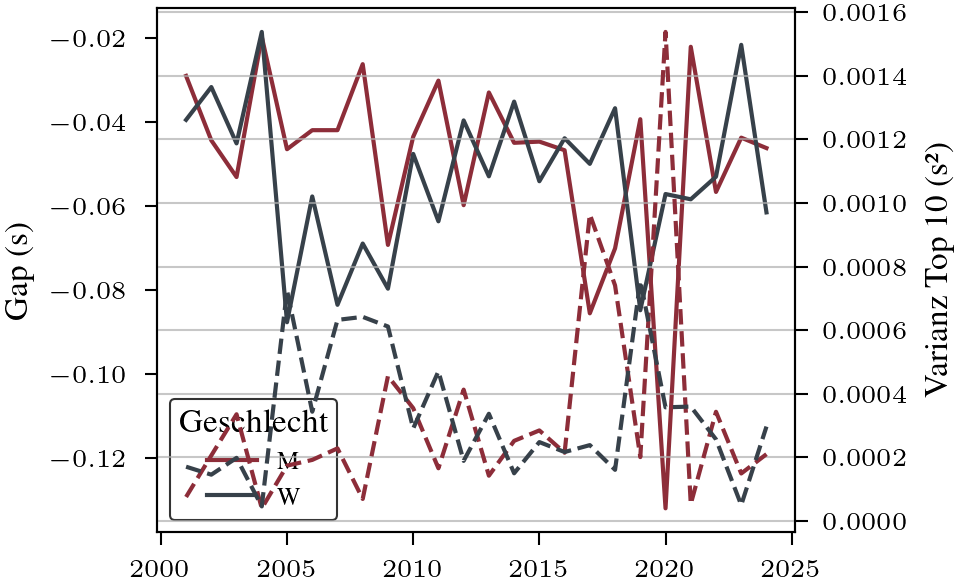

In [8]:
ax1 = plt.gca()
for g in metrics['geschlecht'].unique():
    subset = metrics[metrics['geschlecht'] == g]
    ax1.plot(subset['jahr'], subset['gap_norm'], label=g)
ax1.set_ylabel('Gap (s)')

ax2 = ax1.twinx()
for g in metrics['geschlecht'].unique():
    subset = metrics[metrics['geschlecht'] == g]
    ax2.plot(subset['jahr'], subset['var10_norm'], linestyle='--', label=f'{g} var10')
ax2.set_ylabel('Varianz Top 10 (s²)')
# ax2.set_title('Varianz Top 10 (s²)')

ax1.legend(title="Geschlecht")
plt.grid()
# ax2.legend(title="Geschlecht")

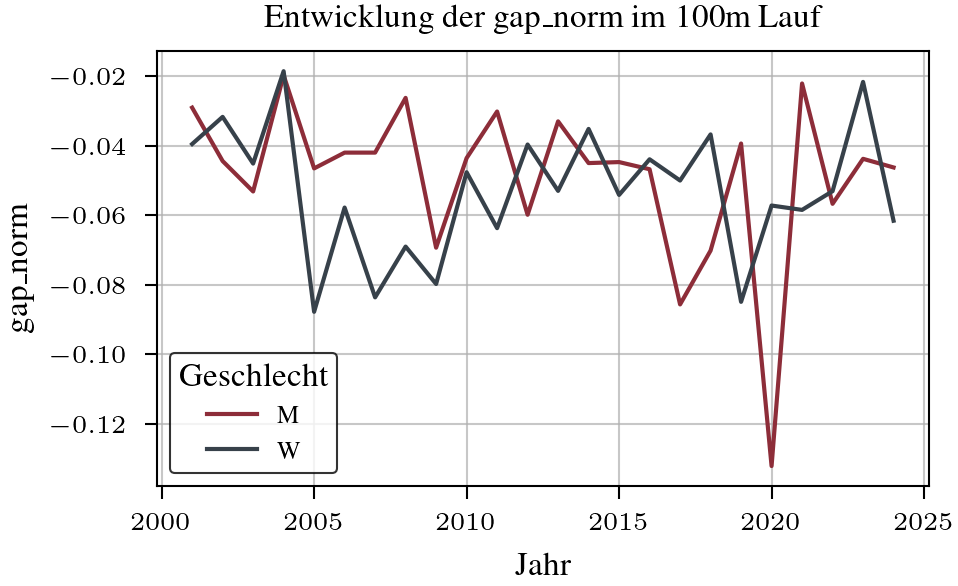

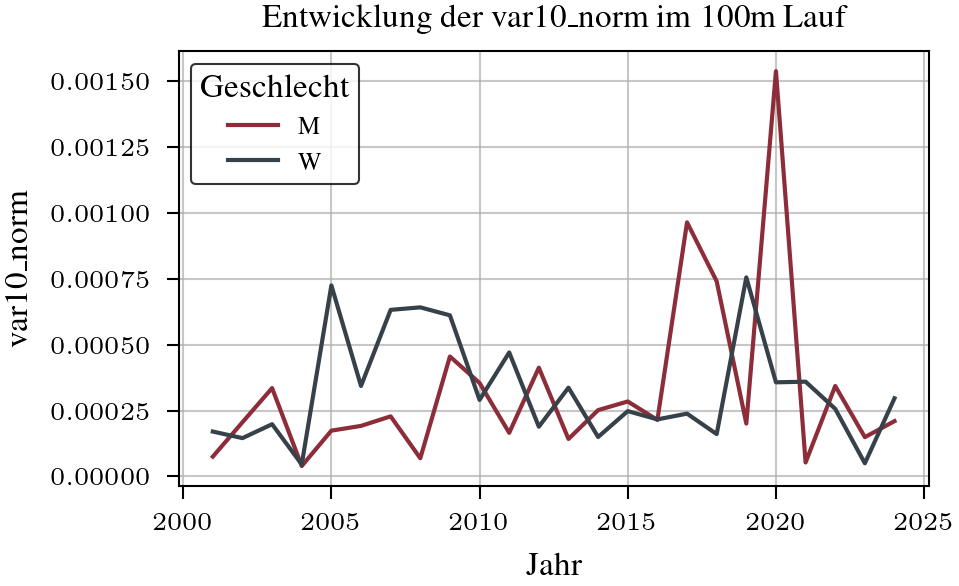

In [9]:
for metric in ["gap_norm", "var10_norm"]:
    for g in metrics["geschlecht"].unique():
        subset = metrics[metrics["geschlecht"] == g]
        plt.plot(subset["jahr"], subset[metric], label=g)

    plt.xlabel("Jahr")
    plt.ylabel(metric)
    plt.title(f"Entwicklung der {metric} im 100m Lauf")
    plt.legend(title="Geschlecht")
    plt.grid()
    plt.show()

In [10]:
def bootstrap_diff(x, y, n=10000):
    diffs = []
    for _ in range(n):
        xs = np.random.choice(x, size=len(x), replace=True)
        ys = np.random.choice(y, size=len(y), replace=True)
        diffs.append(xs.mean() - ys.mean())
    return np.percentile(diffs, [2.5, 97.5])

In [11]:
m = metrics[metrics["geschlecht"] == "M"]["gap_norm"].dropna().values
w = metrics[metrics["geschlecht"] == "W"]["gap_norm"].dropna().values

ci = bootstrap_diff(m, w)
ci

array([-0.00785769,  0.01540264])